# Social Studies with LLM

#### Run MMLU without Logits:

In [1]:
import os
from copy import deepcopy

import dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from social_studies.source.data_connectors.mmlu_pro import (
    run_test_set,
    ExperimentInput,
    ExperimentOutput,
    HistoryMessage,
)
from social_studies.source.result_analysis.analyzer import analyse_results

dotenv.load_dotenv("../.env")

%load_ext autoreload
%autoreload 2

In [ ]:
USED_ENDPOINT = "L3S-TGI"
# USED_ENDPOINT = "LMStudio"


ALL_LLMs = {
    "interweb": ChatOpenAI(
        model="gemma3:1b",
        base_url="https://interweb.l3s.uni-hannover.de/v1",
        api_key=os.getenv("INTERWEB_API_KEY"),
    ),
    "LMStudio": ChatOpenAI(
        model="qwen2.5-0.5b-instruct", base_url="http://127.0.0.1:1234/v1", api_key=""
    ),
    "L3S-TGI": ChatOpenAI(
        model="Qwen/Qwen2.5-0.5B-Instruct",
        base_url="http://localhost:8000/v1",
        api_key="",
    ),
}

In [4]:
def single_model_long_output(input: ExperimentInput):
    used_options = {"temperature": 0.0, "top_p": 0.0001}
    llm = ALL_LLMs[USED_ENDPOINT]
    messages = [
        SystemMessage(
            "Can you answer the following question as accurately as possible? Explain your answer, putting the answer in the form (X) at the end of your response"
        ),
        HumanMessage(input.example_questions + "\n\n" + input.question),
    ]
    ai_msg = llm.invoke(
        messages, **used_options
    )  # FIXME: different from original use temperature 0.0 and top_k 1

    return ExperimentOutput(
        number_of_agents=1,
        used_input_tokens=ai_msg.usage_metadata["input_tokens"],
        used_output_tokens=ai_msg.usage_metadata["output_tokens"],
        used_rounds=1,
        final_answer=ai_msg.content,
        history=[
            HistoryMessage(
                input_context=messages,
                answer=ai_msg.content,
                model_name=ai_msg.response_metadata["model_name"],
                agent_id=0,
                options=used_options,
            )
        ],
    )

In [15]:
NO_OF_ROUNDS = 2
NO_OF_AGENTS = 3


def multiagent_debate(input: ExperimentInput):
    used_options = {"temperature": 0.5, "top_p": 0.0001}
    llm = ALL_LLMs[USED_ENDPOINT]
    history = []

    total_used_input_tokens = 0
    total_used_output_tokens = 0

    def call_llm(messages, agent_id):
        nonlocal total_used_input_tokens, total_used_output_tokens
        ai_msg = llm.invoke(messages, **used_options)

        history.append(
            HistoryMessage(
                input_context=messages,
                answer=ai_msg.content,
                agent_id=agent_id,
                model_name=ai_msg.response_metadata["model_name"],
                options=used_options,
            )
        )

        total_used_input_tokens += ai_msg.usage_metadata["input_tokens"]
        total_used_output_tokens += ai_msg.usage_metadata["output_tokens"]

        return ai_msg.content

    last_agent_answers = []

    for r in range(1, NO_OF_ROUNDS + 1):
        if not last_agent_answers:
            messages = {
                a: [
                    SystemMessage(
                        "Can you answer the following question as accurately as possible? Explain your answer, putting the answer in the form (X) at the end of your response"
                    ),
                    HumanMessage(input.example_questions + "\n\n" + input.question),
                ]
                for a in range(NO_OF_AGENTS)
            }

        else:
            messages = {
                a: [
                    SystemMessage(
                        "Can you answer the following question as accurately as possible? Explain your answer, putting the answer in the form (X) at the end of your response"
                    ),
                    HumanMessage(input.example_questions + "\n\n" + input.question),
                    AIMessage(last_agent_answers[a]),
                    HumanMessage(
                        f"These are the solutions to the problem from other agents: {'\n\n'.join(last_agent_answers)} Using the reasoning from other agents as additional advice, can you give an updated answer? Examine your solution and that other agents. Put your answer in the form (X) at the end of your response."
                    ),
                ]
                for a in range(NO_OF_AGENTS)
            }

        last_agent_answers = [call_llm(messages[a], a) for a in range(NO_OF_AGENTS)]

        if r == 1:
            answers_at_beginning = deepcopy(last_agent_answers)
        elif r == NO_OF_ROUNDS:
            answers_at_end = deepcopy(last_agent_answers)

    return ExperimentOutput(
        number_of_agents=NO_OF_AGENTS,
        used_input_tokens=total_used_input_tokens,
        used_output_tokens=total_used_output_tokens,
        used_rounds=NO_OF_ROUNDS,
        final_answer="",
        history=history,
        answers_at_beginning=answers_at_beginning,
        answers_at_end=answers_at_end,
    )

In [10]:
WORKERS = 50

In [ ]:
run_test_set(single_model_baseline, "standard", num_workers=WORKERS)

In [ ]:
run_test_set(single_model_long_output, "standard_long_output", num_workers=WORKERS)

In [16]:
run_test_set(multiagent_debate, "multi_agent_debate", num_workers=WORKERS // 5)


  3%|▎         | 408/12032 [1:34:29<44:51:54, 13.89s/it]


APIConnectionError: Connection error.

In [25]:
results = analyse_results(
    "/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/social_studies/test.json"
)

100%|██████████| 198/198 [00:00<00:00, 34243.45it/s]

extraction failed output="Let's think step by step:\n\n1. The question asks about a marketing research firm that contracts with clients to conduct a complete marketing research project.\n\n2. A marketing research firm typically contracts with clients to gather data, analyze it, and produce reports.\n\n3. Among the given options, the one that best fits this description is (H): Research firm.\n\n4. A research firm is specifically designed to conduct marketing research projects, which matches the description given in the question.\n\n5. The other options do", do a random guess:
extraction failed output="Let's think step by step:\n\n1. The question asks about the process of ensuring that one individual does not carry the burden of a whole work task.\n2. Work distribution is the process of dividing tasks among multiple individuals or teams to share the workload.\n3. Work distribution is not the process of ensuring that one individual does not carry the burden of a whole work task.\n4. Work 

In [29]:
results["total"].precision_answered("A")

0.2420091324200913

<BarContainer object of 10 artists>

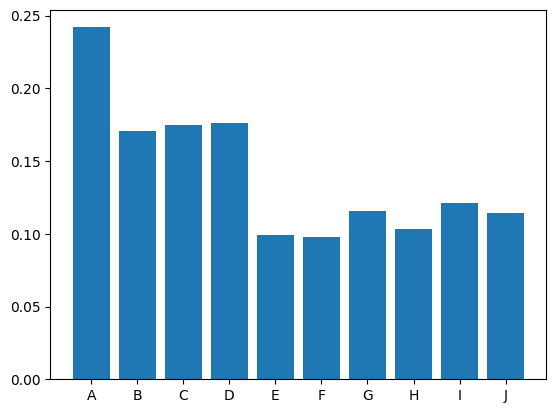

In [34]:
import matplotlib.pyplot as plt

data = {}
for l in results["total"].labels:
    data[l] = results["total"].precision_answered(l)
plt.bar(data.keys(), data.values())

In [ ]:
results["total"]